# Figure 1: Inter-Scholar Thematic Distinctiveness (Revised)

- Scholar order: Hunt, Mowen, Pan, Crompton, Fletcher, Escobar
- Font: Times New Roman
- Color: white-to-deep-indigo gradient
- Diagonal: hatching
- Cell gaps for modern look
- DPI: 500

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

matplotlib.rcParams["font.family"] = "serif"
matplotlib.rcParams["font.serif"] = ["Times New Roman"]

DATA = Path("../8. Results/scholar_distinctiveness.csv")
FIG_DIR = Path("../8. Results/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

sd = pd.read_csv(DATA, skiprows=1)
print(f"Loaded {len(sd)} rows")
sd.head()

Loaded 60 rows


,model,scholar_a,scholar_b,lex_jaccard,syn_jaccard,tfidf_cos
0,ChatGPT 5 (Auto),Hunt,Pan,0.333333,0.333333,0.793444
1,ChatGPT 5 (Auto),Hunt,Mowen,0.500000,0.500000,0.844642
2,ChatGPT 5 (Auto),Hunt,Fletcher,0.200000,0.333333,0.784575
3,ChatGPT 5 (Auto),Hunt,Escobar,0.200000,0.500000,0.766131
4,ChatGPT 5 (Auto),Hunt,Crompton,0.200000,0.333333,0.735097


In [2]:
scholars = ["Hunt", "Mowen", "Pan", "Crompton", "Fletcher", "Escobar"]

mat = np.full((6, 6), np.nan)
for i, a in enumerate(scholars):
    for j, b in enumerate(scholars):
        if i == j:
            continue
        sub = sd[((sd.scholar_a == a) & (sd.scholar_b == b)) |
                 ((sd.scholar_a == b) & (sd.scholar_b == a))]
        if len(sub):
            mat[i, j] = sub["syn_jaccard"].mean()

row_means = np.nanmean(mat, axis=1)

print("Scholar order:")
for s, m in zip(scholars, row_means):
    print(f"  {s}: {m:.3f}")

Scholar order:
  Hunt: 0.300
  Mowen: 0.316
  Pan: 0.309
  Crompton: 0.256
  Fletcher: 0.253
  Escobar: 0.159


In [3]:
cmap = LinearSegmentedColormap.from_list('white_indigo', [
    (0.00, "#F0F4FA"),
    (0.15, "#D6E2F0"),
    (0.30, "#A8C4E0"),
    (0.50, "#6A9FD0"),
    (0.70, "#3A72B0"),
    (0.85, "#1E4D8C"),
    (1.00, "#0A2463"),
], N=256)

C:\Users\wsgar\AppData\Local\Temp\ipykernel_67968\1919901744.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ..\8. Results\figures\Figure1_ScholarMatrix.png  (430,055 bytes)


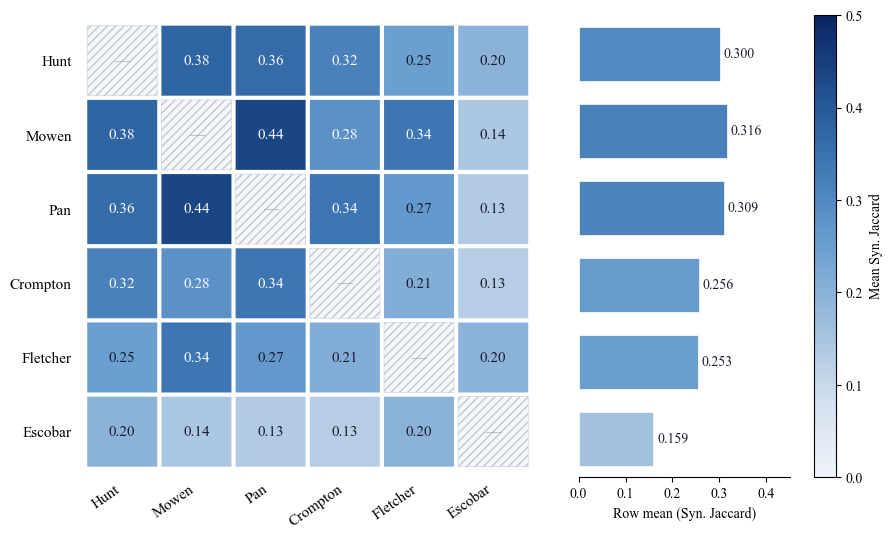

In [4]:
fig = plt.figure(figsize=(10.0, 6.0))
gs = fig.add_gridspec(1, 3, width_ratios=[5.6, 2.4, 0.25], wspace=0.10)
ax = fig.add_subplot(gs[0, 0])
ax_mean = fig.add_subplot(gs[0, 1])
ax_cb = fig.add_subplot(gs[0, 2])

n = len(scholars)
cell_size = 1.0
gap = 0.06

for i in range(n):
    for j in range(n):
        x0 = j * (cell_size + gap)
        y0 = i * (cell_size + gap)
        if i == j:
            rect = mpatches.FancyBboxPatch(
                (x0, y0), cell_size, cell_size,
                boxstyle="round,pad=0",
                facecolor="#F5F7FA", edgecolor="#D0D5DD", linewidth=0.5)
            ax.add_patch(rect)
            rect_h = mpatches.FancyBboxPatch(
                (x0, y0), cell_size, cell_size,
                boxstyle="round,pad=0",
                facecolor="none", edgecolor="#C0C8D4",
                linewidth=0, hatch="////")
            ax.add_patch(rect_h)
            ax.text(x0 + cell_size/2, y0 + cell_size/2, "\u2014",
                    ha="center", va="center", color="#999", fontsize=11)
        else:
            v = mat[i, j]
            color = cmap(v / 0.5)
            rect = mpatches.FancyBboxPatch(
                (x0, y0), cell_size, cell_size,
                boxstyle="round,pad=0",
                facecolor=color, edgecolor="white", linewidth=0)
            ax.add_patch(rect)
            tc = "white" if v > 0.28 else "#1a1a2e"
            ax.text(x0 + cell_size/2, y0 + cell_size/2, f"{v:.2f}",
                    ha="center", va="center", color=tc, fontsize=11)

total = n * cell_size + (n - 1) * gap
ax.set_xlim(-0.15, total + 0.15)
ax.set_ylim(total + 0.15, -0.15)
ax.set_xticks([i * (cell_size + gap) + cell_size/2 for i in range(n)])
ax.set_yticks([i * (cell_size + gap) + cell_size/2 for i in range(n)])
ax.set_xticklabels(scholars, rotation=35, ha="right", fontsize=11)
ax.set_yticklabels(scholars, fontsize=11)
ax.tick_params(axis="both", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_aspect("equal")

bar_colors = [cmap(m / 0.5) for m in row_means]
ax_mean.barh(range(n), row_means, color=bar_colors,
             edgecolor="white", linewidth=0.5, height=0.7)
x_upper = max(0.45, float(np.nanmax(row_means)) + 0.10)
for i, m in enumerate(row_means):
    ax_mean.text(m + 0.008, i, f"{m:.3f}", va="center", fontsize=10,
                 color="#1a1a2e")
ax_mean.set_xlim(0, x_upper)
ax_mean.set_ylim(n - 0.5, -0.5)
ax_mean.set_xticks([0.0, 0.1, 0.2, 0.3, 0.4])
ax_mean.tick_params(axis="y", which="both", left=False, labelleft=False)
ax_mean.set_xlabel("Row mean (Syn. Jaccard)", fontsize=10)
ax_mean.spines["left"].set_visible(False)
ax_mean.spines["top"].set_visible(False)
ax_mean.spines["right"].set_visible(False)

norm = plt.Normalize(vmin=0, vmax=0.5)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax_cb)
cbar.set_label("Mean Syn. Jaccard", fontsize=10)

plt.tight_layout()

out_path = FIG_DIR / "Figure1_ScholarMatrix.png"
fig.savefig(out_path, dpi=500, bbox_inches="tight", facecolor="white")
print(f"Saved: {out_path}  ({out_path.stat().st_size:,} bytes)")
plt.show()